# 🛒 Supermarket Sales Analysis

## Data Analysis → Visualization → Business Insights

This notebook analyzes the **SuperMarket Analysis.csv** dataset.

### Objectives
- Understand the dataset
- Check data quality
- Explore sales performance
- Analyze products, branches, customers and payments
- Study sales over time
- Investigate relationships between variables
- Extract useful business insights
- Prepare the analysis for a Streamlit dashboard

### Main workflow

**Load → Understand → Clean → Explore → Visualize → Interpret → Prepare Dashboard**


## 1. Business Questions

We will use the data to answer:

1. How much total sales were generated?
2. How many products were sold?
3. How many transactions were made?
4. What is the average sales value per transaction?
5. Which product line generates the most sales?
6. Which branch performs best?
7. How do sales change over time?
8. Which payment method is most frequently used?
9. How do customer types contribute to sales?
10. What is the relationship between quantity and sales?
11. What do customer ratings look like?


## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [2]:
file_path = "SuperMarket Analysis.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## 4. Understand the Dataset

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Rows: 1,000
Columns: 17


In [5]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,1000,1000,750-67-8428,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,1000,3,Alex,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,3,Yangon,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer type,1000,2,Member,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product line,1000,6,Fashion accessories,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit price,1000.0,NaN,NaN,NaN,55.67213,26.494628,10.08,32.875,55.23,77.935,99.96
Quantity,1000.0,NaN,NaN,NaN,5.51,2.923431,1.0,3.0,5.0,8.0,10.0
Tax 5%,1000.0,NaN,NaN,NaN,15.379369,11.708825,0.5085,5.924875,12.088,22.44525,49.65
Sales,1000.0,NaN,NaN,NaN,322.966749,245.885335,10.6785,124.422375,253.848,471.35025,1042.65


## 5. Data Quality Check

We check missing values, duplicates, and important data types before analysis.

In [8]:
missing = df.isnull().sum()
print("Missing values:")
display(missing[missing > 0].to_frame("Missing Values"))

print(f"\nDuplicate rows: {df.duplicated().sum():,}")


Missing values:


,Missing Values



Duplicate rows: 0


## 6. Prepare Date and Time

In [9]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_Name"] = df["Date"].dt.day_name()

df[["Date", "Time", "Year", "Month", "Month_Name", "Day_Name"]].head()


,Date,Time,Year,Month,Month_Name,Day_Name
0,2019-01-05,1:08:00 PM,2019,1,January,Saturday
1,2019-03-08,10:29:00 AM,2019,3,March,Friday
2,2019-03-03,1:23:00 PM,2019,3,March,Sunday
3,2019-01-27,8:33:00 PM,2019,1,January,Sunday
4,2019-02-08,10:37:00 AM,2019,2,February,Friday


## 7. Explore Categorical Variables

In [10]:
categorical_columns = [
    "Branch", "City", "Customer type", "Gender",
    "Product line", "Payment"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())



Branch:
Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

City:
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

Customer type:
Customer type
Member    565
Normal    435
Name: count, dtype: int64

Gender:
Gender
Female    571
Male      429
Name: count, dtype: int64

Product line:
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Payment:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


## 8. Key Performance Indicators (KPIs)

In [11]:
total_sales = df["Sales"].sum()
total_quantity = df["Quantity"].sum()
transactions = len(df)
average_sale = df["Sales"].mean()
average_rating = df["Rating"].mean()
total_gross_income = df["gross income"].sum()

kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Quantity",
        "Transactions",
        "Average Sale",
        "Average Rating",
        "Total Gross Income"
    ],
    "Value": [
        total_sales,
        total_quantity,
        transactions,
        average_sale,
        average_rating,
        total_gross_income
    ]
})

kpis


,KPI,Value
0,Total Sales,322966.749000
1,Total Quantity,5510.000000
2,Transactions,1000.000000
3,Average Sale,322.966749
4,Average Rating,6.972700
5,Total Gross Income,15379.369000


## 9. Sales by Product Line

In [12]:
sales_by_product = (
    df.groupby("Product line")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_product


,Product line,Sales
0,Food and beverages,56144.8440
1,Sports and travel,55122.8265
2,Electronic accessories,54337.5315
3,Fashion accessories,54305.8950
4,Home and lifestyle,53861.9130
5,Health and beauty,49193.7390


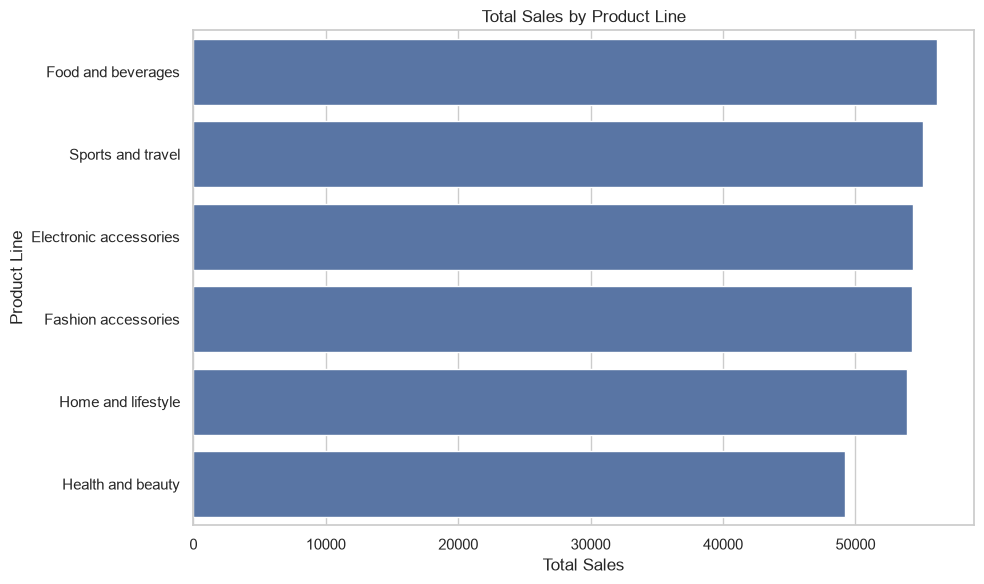

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=sales_by_product, x="Sales", y="Product line")
plt.title("Total Sales by Product Line")
plt.xlabel("Total Sales")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()


### Interpretation

The product line at the top of the sorted table/chart is the highest sales contributor. Use the result to identify products that may deserve attention in stock planning and sales strategy.

## 10. Quantity Sold by Product Line

In [14]:
quantity_by_product = (
    df.groupby("Product line")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

quantity_by_product


,Product line,Quantity
0,Electronic accessories,971
1,Food and beverages,952
2,Sports and travel,920
3,Home and lifestyle,911
4,Fashion accessories,902
5,Health and beauty,854


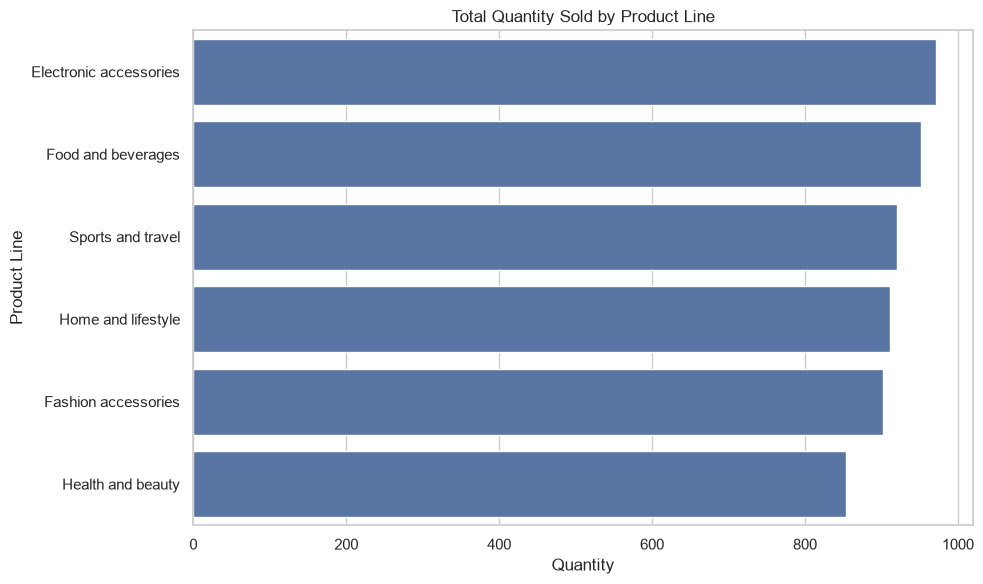

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=quantity_by_product, x="Quantity", y="Product line")
plt.title("Total Quantity Sold by Product Line")
plt.xlabel("Quantity")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()


## 11. Sales by Branch

In [16]:
sales_by_branch = (
    df.groupby("Branch")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_branch


,Branch,Sales
0,Giza,110568.7065
1,Alex,106200.3705
2,Cairo,106197.6720


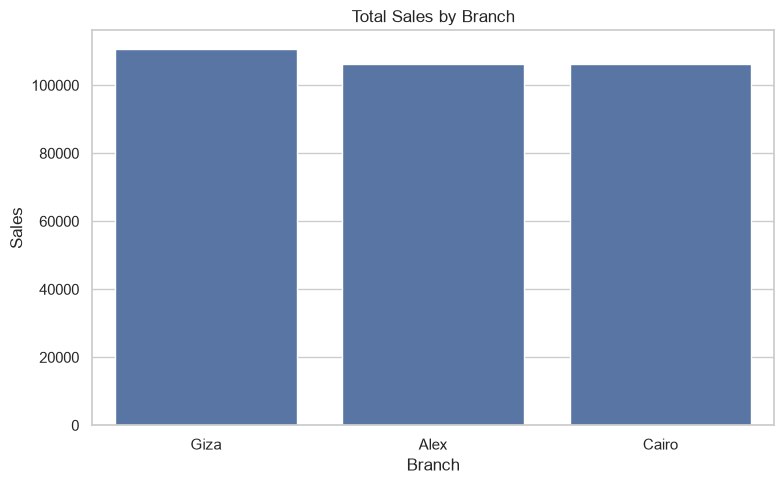

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_branch, x="Branch", y="Sales")
plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 12. Sales by City

In [18]:
sales_by_city = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_city


,City,Sales
0,Naypyitaw,110568.7065
1,Yangon,106200.3705
2,Mandalay,106197.6720


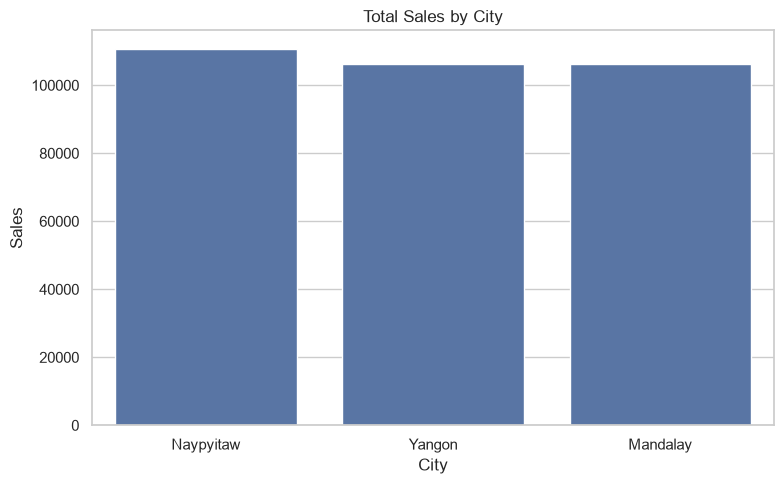

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_city, x="City", y="Sales")
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 13. Customer Type Analysis

In [20]:
sales_by_customer = (
    df.groupby("Customer type")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

sales_by_customer


,Customer type,Sales
0,Member,189694.764
1,Normal,133271.985


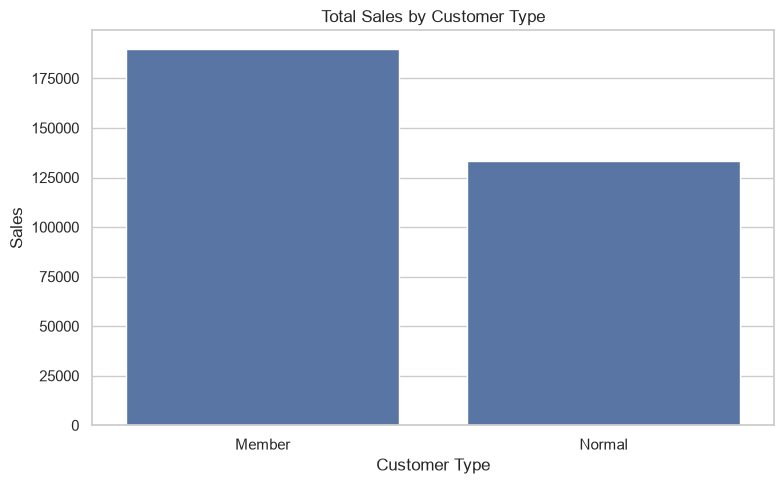

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_customer, x="Customer type", y="Sales")
plt.title("Total Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 14. Gender Analysis

In [22]:
sales_by_gender = df.groupby("Gender")["Sales"].sum().reset_index()
sales_by_gender


,Gender,Sales
0,Female,194671.8375
1,Male,128294.9115


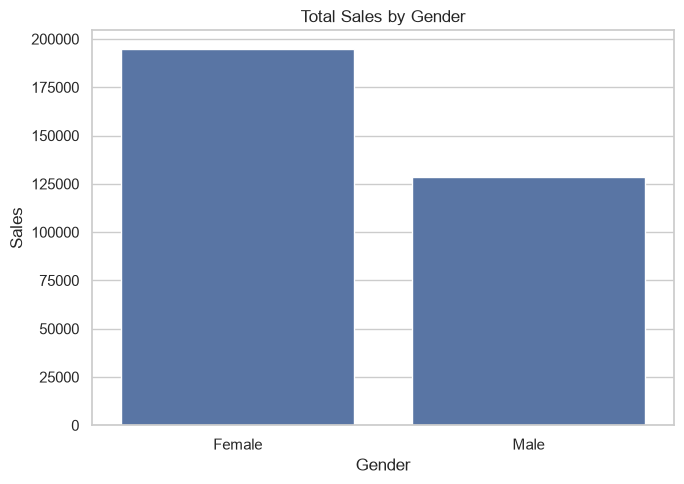

In [23]:
plt.figure(figsize=(7, 5))
sns.barplot(data=sales_by_gender, x="Gender", y="Sales")
plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


## 15. Payment Method Analysis

In [24]:
payment_counts = df["Payment"].value_counts().reset_index()
payment_counts.columns = ["Payment", "Transactions"]
payment_counts


,Payment,Transactions
0,Ewallet,345
1,Cash,344
2,Credit card,311


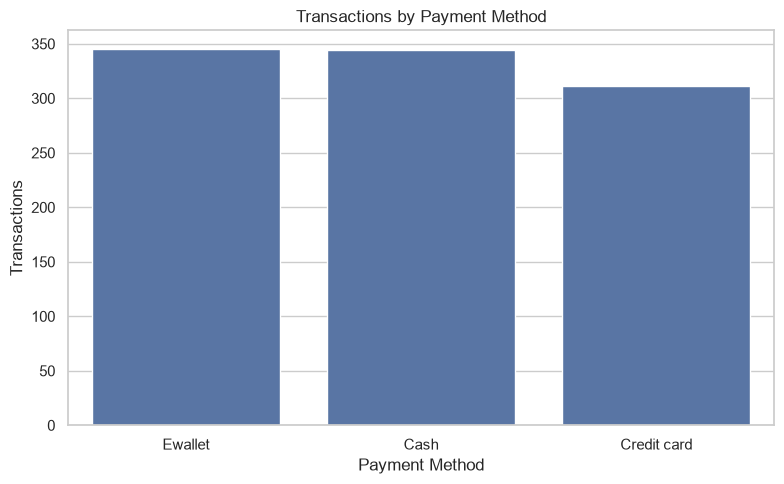

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=payment_counts, x="Payment", y="Transactions")
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Transactions")
plt.tight_layout()
plt.show()


## 16. Sales Over Time

In [26]:
daily_sales = (
    df.groupby("Date")["Sales"]
      .sum()
      .reset_index()
      .sort_values("Date")
)

daily_sales.head()


,Date,Sales
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


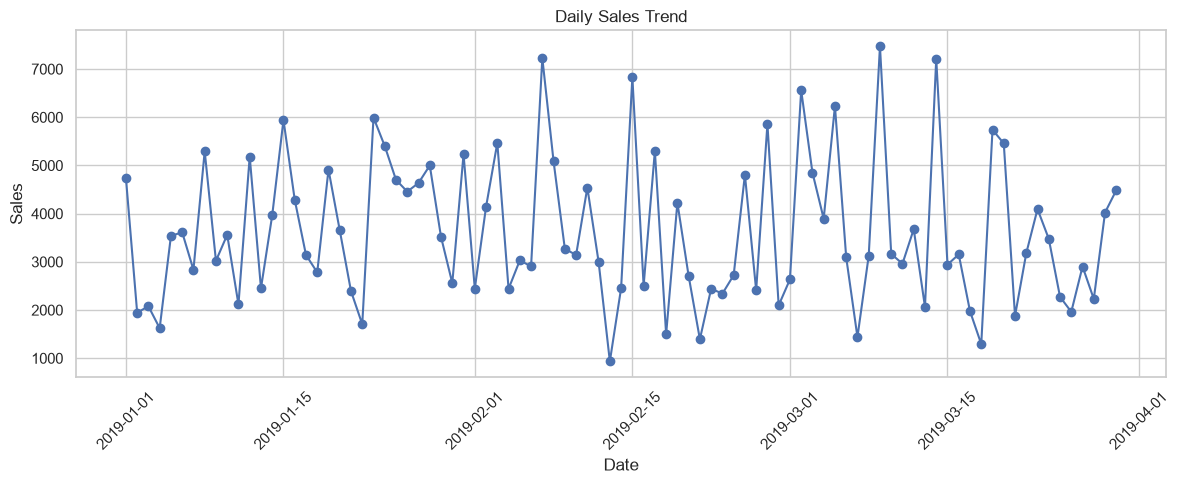

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales["Date"], daily_sales["Sales"], marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month"] = monthly_sales["Date"].astype(str)
monthly_sales = monthly_sales.drop(columns="Date")

monthly_sales


,Sales,Month
0,116291.868,2019-01
1,97219.374,2019-02
2,109455.507,2019-03


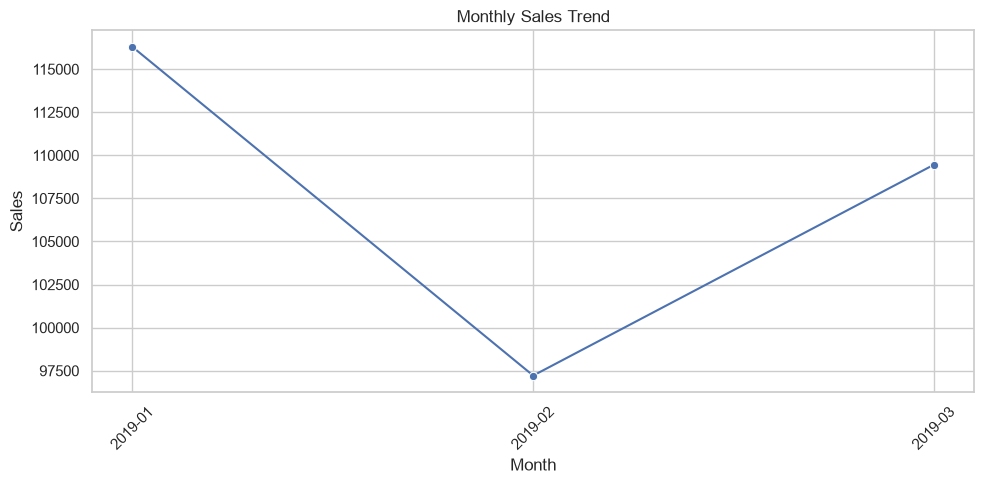

In [29]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 17. Quantity vs Sales

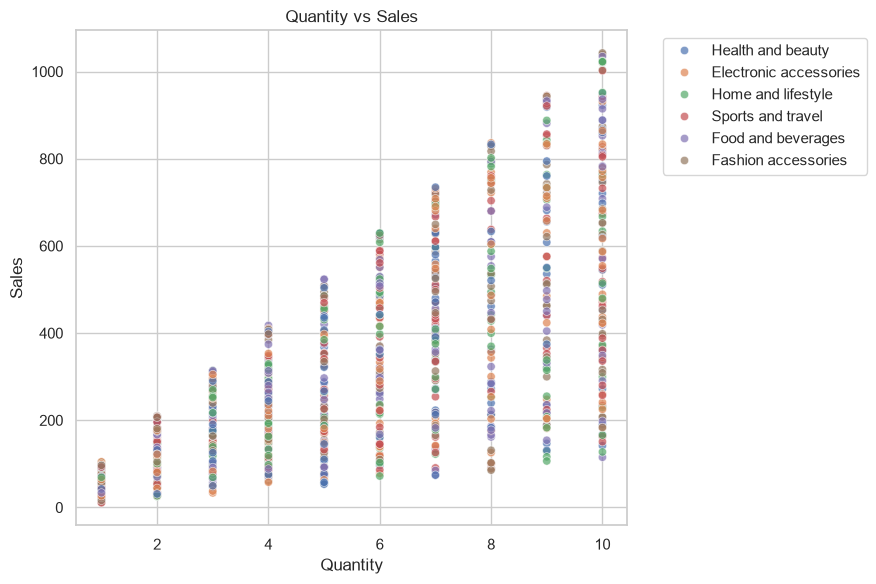

In [30]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales",
    hue="Product line",
    alpha=0.7
)
plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [31]:
correlation = df["Quantity"].corr(df["Sales"])
print(f"Correlation between Quantity and Sales: {correlation:.3f}")


Correlation between Quantity and Sales: 0.706


## 18. Customer Ratings

In [32]:
df["Rating"].describe().round(2)


count    1000.00
mean        6.97
std         1.72
min         4.00
25%         5.50
50%         7.00
75%         8.50
max        10.00
Name: Rating, dtype: float64

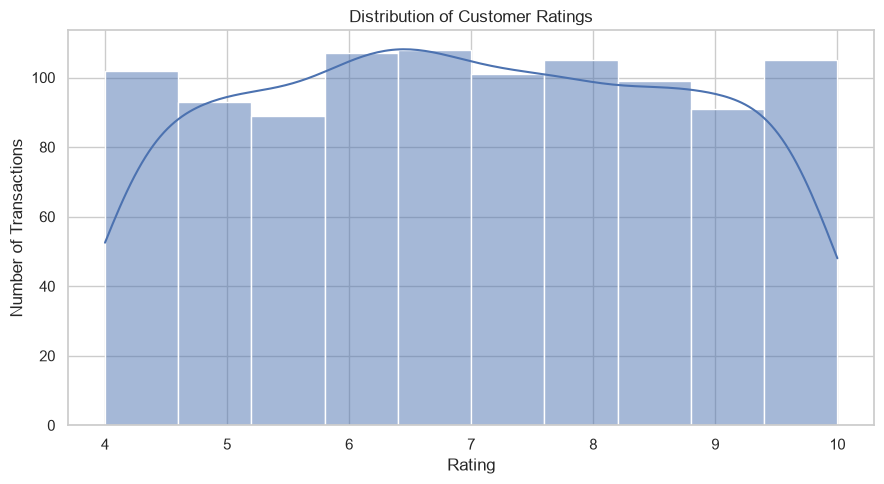

In [33]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Rating", bins=10, kde=True)
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


## 19. Gross Income by Product Line

In [34]:
gross_income_product = (
    df.groupby("Product line")["gross income"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

gross_income_product


,Product line,gross income
0,Food and beverages,2673.5640
1,Sports and travel,2624.8965
2,Electronic accessories,2587.5015
3,Fashion accessories,2585.9950
4,Home and lifestyle,2564.8530
5,Health and beauty,2342.5590


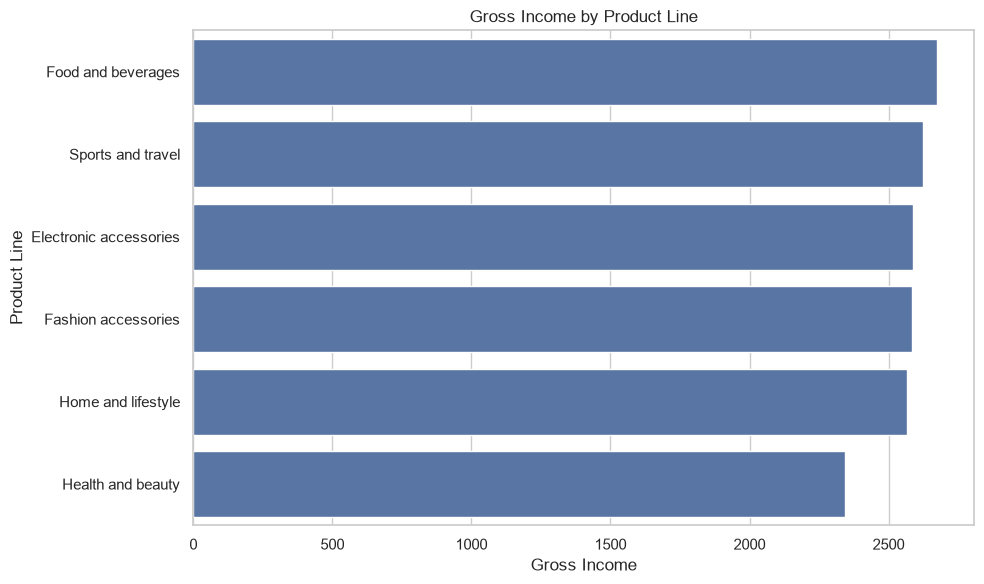

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=gross_income_product, x="gross income", y="Product line")
plt.title("Gross Income by Product Line")
plt.xlabel("Gross Income")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()


## 20. Sales by Product Line and Branch

In [36]:
branch_product_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Product line",
    columns="Branch",
    aggfunc="sum"
)

branch_product_sales


Branch,Alex,Cairo,Giza
Product line,,,
Electronic accessories,18317.1135,17051.4435,18968.9745
Fashion accessories,16332.5085,16413.3165,21560.0700
Food and beverages,17163.1005,15214.8885,23766.8550
Health and beauty,12597.7530,19980.6600,16615.3260
Home and lifestyle,22417.1955,17549.1645,13895.5530
Sports and travel,19372.6995,19988.1990,15761.9280


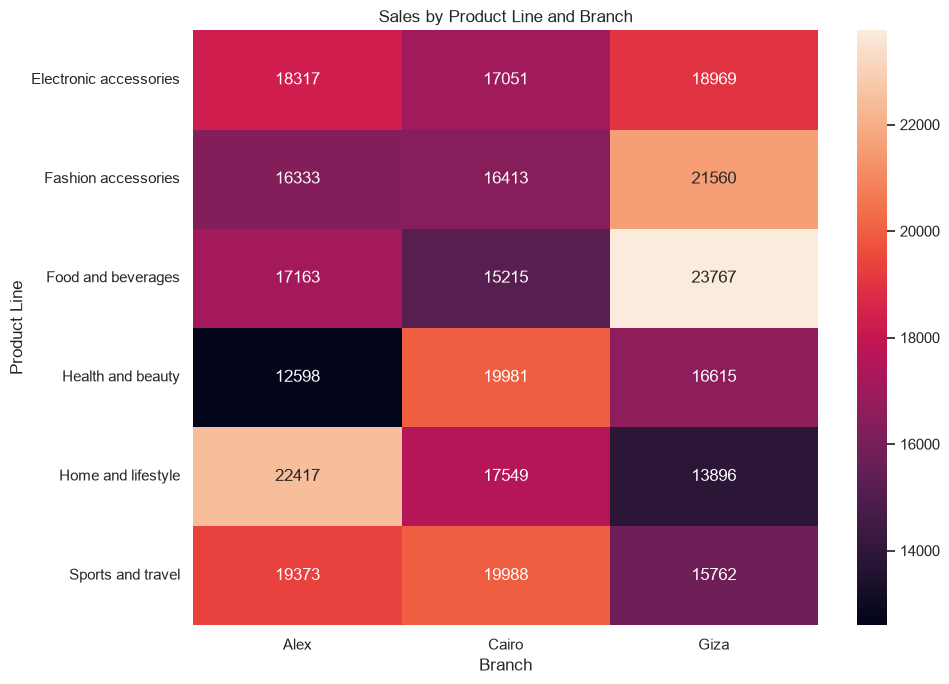

In [37]:
plt.figure(figsize=(10, 7))
sns.heatmap(branch_product_sales, annot=True, fmt=".0f")
plt.title("Sales by Product Line and Branch")
plt.xlabel("Branch")
plt.ylabel("Product Line")
plt.tight_layout()
plt.show()


## 21. Key Business Findings

In [38]:
best_product = sales_by_product.iloc[0]
best_branch = sales_by_branch.iloc[0]
top_payment = payment_counts.iloc[0]

print("KEY FINDINGS")
print("-" * 60)
print(f"Highest-sales product line: {best_product['Product line']}")
print(f"Sales: {best_product['Sales']:,.2f}")
print()
print(f"Highest-sales branch: {best_branch['Branch']}")
print(f"Sales: {best_branch['Sales']:,.2f}")
print()
print(f"Most-used payment method: {top_payment['Payment']}")
print(f"Transactions: {top_payment['Transactions']:,}")
print()
print(f"Average customer rating: {average_rating:.2f}")
print(f"Quantity-Sales correlation: {correlation:.3f}")


KEY FINDINGS
------------------------------------------------------------
Highest-sales product line: Food and beverages
Sales: 56,144.84

Highest-sales branch: Giza
Sales: 110,568.71

Most-used payment method: Ewallet
Transactions: 345

Average customer rating: 6.97
Quantity-Sales correlation: 0.706


## 22. From Jupyter Notebook to Streamlit

The Jupyter Notebook is used to **investigate and understand the data**.

After completing the analysis, we can convert the most useful parts into an interactive Streamlit dashboard.

### Jupyter Notebook
**Analysis + Experimentation + Visualization + Interpretation**

### Streamlit
**KPIs + Filters + Interactive Charts + Tables**

The next file in this project is `app.py`, which turns this analysis into a dashboard.
